# Full RAG Pipeline — Architecture Benchmark

Comparative study of six end-to-end retrieval architectures for the RAG module.  
All architectures work **fully in-memory** — no Qdrant needed.  
Dense vectors are pre-computed once with `all-MiniLM-L6-v2` and shared across architectures.

| # | Architecture | Key idea |
|---|---|---|
| 1 | **Baseline (current)** | Dense + keyword fallback → `_rerank_chunks` (current `search.py` logic) |
| 2 | **DenseOnly** | Pure cosine similarity — no re-ranking |
| 3 | **BM25Only** | Pure BM25Okapi — no vectors |
| 4 | **HybridRRF** | Reciprocal Rank Fusion of dense + BM25 |
| 5 | **HybridRRF+CE** | HybridRRF → cross-encoder re-ranking |
| 6 | **HybridRRF+MMR** | HybridRRF → Maximum Marginal Relevance diversification |

**Experiments:**
1. Architecture comparison — single run, all metrics  
2. Hit@K curves — coverage vs retrieval depth  
3. Stability across random seeds  
4. Sample size sensitivity  
5. Query length breakdown — short / medium / long queries  
6. Diversity analysis — how unique are the top-k results?  
7. Speed vs quality trade-off  

> **Self-retrieval limitation:** synthetic queries come from the same word forms as the chunk,
> so BM25+morphology and cross-encoder advantages are underestimated vs real user queries.

In [1]:
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    mod = import_name or pkg.replace('-', '_')
    if importlib.util.find_spec(mod) is None:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else:
        print(f'{pkg}: OK')

_ensure('rank-bm25', 'rank_bm25')
_ensure('seaborn')
_ensure('pandas')

rank-bm25: OK
seaborn: OK
pandas: OK


In [2]:
import os, random, sys, time, warnings
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from benchmark_rag import (
    load_chunks, SharedResources,
    BaselineRAG, DenseOnlyRAG, BM25OnlyRAG,
    HybridRRFRAG, HybridRRFCrossEncoderRAG, HybridRRFMMRRAG,
    evaluate, evaluate_by_query_length,
    diversity_score, _generate_query, query_length_category,
    HAS_BM25, HAS_ST,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
})

COLORS = {
    'Baseline (current)': '#6c757d',
    'DenseOnly':          '#2196F3',
    'BM25Only':           '#FF9800',
    'HybridRRF':          '#9C27B0',
    'HybridRRF+CE':       '#F44336',
    'HybridRRF+MMR':      '#4CAF50',
}
FALLBACK = ['#6c757d','#2196F3','#FF9800','#9C27B0','#F44336','#4CAF50']

print('HAS_BM25={}, HAS_ST={}'.format(HAS_BM25, HAS_ST))

HAS_BM25=True, HAS_ST=True


## ⚙️ Configuration

Set `DISCIPLINE` to a slug inside your `data/disciplines/` folder.  
Set `SKIP_CE = True` to skip the cross-encoder (avoids the ~80 MB model download).  
**Run this cell once** — dense vectors and BM25 index are shared across all experiments.

In [3]:
DISCIPLINE   = 'math'
SAMPLE_SIZE  = 100
DEFAULT_SEED = 42
DEFAULT_TOPK = 5
SKIP_CE      = False   # True → skip HybridRRF+CE

from dotenv import load_dotenv
load_dotenv()
DISCIPLINES_DIR = os.getenv('DISCIPLINES_DIR', 'data/disciplines')

# ── Load corpus ────────────────────────────────────────────────────────────────
print('Loading corpus ...')
chunks = load_chunks(DISCIPLINES_DIR, DISCIPLINE)
assert chunks, 'No chunks found! Check DISCIPLINES_DIR in .env and PDF files.'
print('Chunks: {}  |  PDFs: {}'.format(len(chunks), len({s for s,_ in chunks})))
print()

# ── Shared resources (dense encoding + BM25) ─────────────────────────────────
shared = SharedResources(chunks)
_ = shared.vectors      # triggers SentenceTransformer encoding — may take ~1 min
if HAS_BM25:
    _ = shared.bm25
else:
    print('rank-bm25 not installed — BM25-based architectures unavailable')
print()

# ── Build architectures ────────────────────────────────────────────────────────
architectures = [BaselineRAG(shared), DenseOnlyRAG(shared)]

if HAS_BM25:
    architectures += [
        BM25OnlyRAG(shared),
        HybridRRFRAG(shared),
        HybridRRFMMRRAG(shared),
    ]

if HAS_BM25 and HAS_ST and not SKIP_CE:
    try:
        from benchmark_rag import _get_cross_encoder
        print('Loading cross-encoder (download on first run) ...')
        _ = _get_cross_encoder()
        architectures.append(HybridRRFCrossEncoderRAG(shared))
        print('HybridRRF+CE: ready')
    except Exception as e:
        print('HybridRRF+CE skipped: ' + str(e))

ARCH_NAMES   = [a.name for a in architectures]
ARCH_COLORS  = [COLORS.get(n, FALLBACK[i]) for i, n in enumerate(ARCH_NAMES)]
METRIC_COLS  = ['Hit@1', 'Hit@3', 'Hit@5', 'Hit@{}'.format(DEFAULT_TOPK), 'MRR', 'Diversity']

print()
print('Architectures ready:', ARCH_NAMES)

Loading corpus ...
Chunks: 539  |  PDFs: 2



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8333.27it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoding 539 chunks with all-MiniLM-L6-v2...


Batches: 100%|██████████| 9/9 [00:02<00:00,  4.16it/s]

  Building BM25 index...



Loading cross-encoder (download on first run) ...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8309.63it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HybridRRF+CE: ready

Architectures ready: ['Baseline (current)', 'DenseOnly', 'BM25Only', 'HybridRRF', 'HybridRRF+MMR', 'HybridRRF+CE']


## Experiment 1 — Architecture Comparison

Single run at default settings. Metrics include **Diversity** (1 - avg pairwise cosine sim of top-k results).

In [9]:
def run_single(seed, sample_size, top_k, arch_list=None):
    if arch_list is None:
        arch_list = architectures
    random.seed(seed)
    texts = [t for _, t in random.sample(chunks, min(sample_size, len(chunks)))]
    rows = []
    for a in arch_list:
        t0  = time.perf_counter()
        m   = evaluate(a, shared, texts, top_k=top_k)
        ela = time.perf_counter() - t0
        m['Time_s']    = ela
        m['Algorithm'] = a.name
        rows.append(m)
    df = pd.DataFrame(rows).set_index('Algorithm')
    return df.drop(columns=['n'], errors='ignore')


df_main = run_single(DEFAULT_SEED, SAMPLE_SIZE, DEFAULT_TOPK)
display(df_main[METRIC_COLS + ['Time_s']].round(4))

,Hit@1,Hit@3,Hit@5,Hit@5,MRR,Diversity,Time_s
Algorithm,,,,,,,
Baseline (current),0.39,0.48,0.57,0.57,0.4467,0.3882,1.5569
DenseOnly,0.02,0.07,0.11,0.11,0.0518,0.2518,0.7323
BM25Only,0.91,1.00,1.00,1.00,0.9517,0.3770,0.0351
HybridRRF,0.20,0.45,0.78,0.78,0.3775,0.3105,0.8151
HybridRRF+MMR,0.02,0.16,0.23,0.23,0.0982,0.4246,1.4775
HybridRRF+CE,0.10,0.26,0.35,0.35,0.1883,0.2882,21.5436


In [ ]:
# ── Grouped bar chart ──────────────────────────────────────────────────────────
plot_metrics = [c for c in METRIC_COLS if c in df_main.columns]
x       = np.arange(len(plot_metrics))
n_arch  = len(df_main)
width   = 0.8 / n_arch

fig, ax = plt.subplots(figsize=(13, 5))
for i, (arch, row) in enumerate(df_main.iterrows()):
    offset = (i - n_arch / 2 + 0.5) * width
    vals   = [row.get(m, 0.0) for m in plot_metrics]
    bars   = ax.bar(x + offset, vals, width * 0.9,
                    color=COLORS.get(arch, FALLBACK[i]), label=arch, alpha=0.9)
    for bar, val in zip(bars, vals):
        if val > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.007,
                    '{:.2f}'.format(val), ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.13)
ax.set_ylabel('Score')
ax.set_title('Architecture comparison — {} | samples={}, top_k={}'.format(
    DISCIPLINE, SAMPLE_SIZE, DEFAULT_TOPK))
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('rag_01_comparison.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Heatmap: raw + normalised ──────────────────────────────────────────────────
score_df = df_main[plot_metrics].copy()

normed = score_df.copy()
for col in plot_metrics:
    rng = normed[col].max() - normed[col].min()
    normed[col] = (normed[col] - normed[col].min()) / rng if rng > 1e-9 else 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, max(3, n_arch * 0.75 + 1.5)))

sns.heatmap(score_df, annot=True, fmt='.3f', cmap='YlGn', linewidths=0.5,
            ax=ax1, cbar_kws={'label': 'Score'})
ax1.set_title('Raw scores')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=25, ha='right')

sns.heatmap(normed, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5,
            ax=ax2, cbar_kws={'label': '0=worst, 1=best (per metric)'})
ax2.set_title('Normalised (per-metric min-max)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Performance heatmap — ' + DISCIPLINE, y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('rag_01b_heatmap.png', bbox_inches='tight')
plt.show()

NameError: name 'df_main' is not defined

## Experiment 2 — Hit@K Curves

Coverage growth as retrieval depth increases (k = 1 … 15).  
The minimum k needed to reach 80% Hit rate is marked with a dashed line.

In [ ]:
MAX_K = 15

def hitk_curve(arch, texts, max_k=MAX_K):
    ranks = []
    for chunk_text in texts:
        q = _generate_query(chunk_text)
        if not q:
            continue
        results = arch.retrieve(q, top_k=max_k)
        rank = next(
            (i for i, r in enumerate(results, 1) if r.strip() == chunk_text.strip()),
            None,
        )
        ranks.append(rank)
    n = len(ranks)
    return [sum(1 for r in ranks if r is not None and r <= k) / n
            for k in range(1, max_k + 1)]

random.seed(DEFAULT_SEED)
texts_hitk = [t for _, t in random.sample(chunks, min(SAMPLE_SIZE, len(chunks)))]

curves = {}
for a in architectures:
    curves[a.name] = hitk_curve(a, texts_hitk)
    print('  {} Hit@{} = {:.3f}'.format(a.name, MAX_K, curves[a.name][-1]))

ks = list(range(1, MAX_K + 1))
fig, ax = plt.subplots(figsize=(11, 5))
for arch_name, curve in curves.items():
    ax.plot(ks, curve, marker='o', ms=4, lw=2,
            color=COLORS.get(arch_name), label=arch_name)

ax.axhline(0.8, ls='--', lw=1, color='grey', alpha=0.6, label='Hit = 0.80 target')
ax.set_xlabel('k  (retrieval depth)')
ax.set_ylabel('Hit@k')
ax.set_title('Hit@K curves — {} | samples={}, seed={}'.format(
    DISCIPLINE, SAMPLE_SIZE, DEFAULT_SEED))
ax.set_xticks(ks)
ax.legend(framealpha=0.9, fontsize=9, ncol=2)
ax.yaxis.grid(True, alpha=0.4)
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('rag_02_hitk_curves.png', bbox_inches='tight')
plt.show()

## Experiment 3 — Stability Across Random Seeds

Does the ranking change when we evaluate on a different sample?  
10 seeds × all architectures. Narrow boxes = stable estimates.

In [ ]:
SEEDS = [0, 7, 42, 99, 137, 256, 314, 512, 777, 1024]

stability = {n: [] for n in ARCH_NAMES}
for seed in SEEDS:
    df_s = run_single(seed, SAMPLE_SIZE, DEFAULT_TOPK)
    for arch in ARCH_NAMES:
        stability[arch].append(df_s.loc[arch, 'MRR'])
    print('  seed={} done'.format(seed))

stab_df = pd.DataFrame(stability, index=SEEDS)
stab_df.index.name = 'seed'
print()
display(stab_df.agg(['mean', 'std']).round(4))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
ax = axes[0]
bp = ax.boxplot([stab_df[n].values for n in ARCH_NAMES],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ARCH_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(ARCH_NAMES) + 1))
ax.set_xticklabels(ARCH_NAMES, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('MRR')
ax.set_title('MRR distribution — {} seeds'.format(len(SEEDS)))
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Mean ± std
ax = axes[1]
means = stab_df.mean()
stds  = stab_df.std()
bars  = ax.bar(ARCH_NAMES, means, yerr=stds, capsize=5,
               color=ARCH_COLORS, alpha=0.85, width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('MRR (mean \u00b1 std)')
ax.set_title('Mean MRR with standard deviation')
ax.set_xticklabels(ARCH_NAMES, rotation=20, ha='right', fontsize=9)
for bar, m, s in zip(bars, means.values, stds.values):
    ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.012,
            '{:.3f}'.format(m), ha='center', va='bottom', fontsize=8)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.suptitle('Stability — ' + DISCIPLINE, fontsize=13)
plt.tight_layout()
plt.savefig('rag_03_stability.png', bbox_inches='tight')
plt.show()

## Experiment 4 — Sample Size Sensitivity

How many samples are needed for a reliable estimate?  
If lines plateau early, smaller benchmarks are sufficient.

In [ ]:
SAMPLE_SIZES = [n for n in [30, 60, 100, 150, 200, 300, 500] if n <= len(chunks)]

ss_mrr  = {n: [] for n in ARCH_NAMES}
ss_hit5 = {n: [] for n in ARCH_NAMES}

for n in SAMPLE_SIZES:
    df_n = run_single(DEFAULT_SEED, n, DEFAULT_TOPK)
    for arch in ARCH_NAMES:
        ss_mrr[arch].append(df_n.loc[arch, 'MRR'])
        ss_hit5[arch].append(df_n.loc[arch, 'Hit@5'])
    print('  n={} done'.format(n))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for arch in ARCH_NAMES:
    kw = dict(marker='o', ms=5, lw=2, color=COLORS.get(arch), label=arch)
    ax1.plot(SAMPLE_SIZES, ss_mrr[arch],  **kw)
    ax2.plot(SAMPLE_SIZES, ss_hit5[arch], **kw)

for ax, title in [(ax1, 'MRR vs sample size'), (ax2, 'Hit@5 vs sample size')]:
    ax.set_xlabel('Sample size')
    ax.set_title('{} — {}'.format(title, DISCIPLINE))
    ax.set_xticks(SAMPLE_SIZES)
    ax.legend(framealpha=0.9, fontsize=8)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

ax1.set_ylabel('MRR')
ax2.set_ylabel('Hit@5')

plt.tight_layout()
plt.savefig('rag_04_sample_size.png', bbox_inches='tight')
plt.show()

## Experiment 5 — Query Length Breakdown

Different architectures excel at different query types:  
- **BM25** tends to dominate for short, exact queries (1-2 terms)  
- **Dense / HybridRRF** tends to dominate for semantic long queries (5+ terms)  
- **Cross-encoder** should help uniformly

Queries are categorised by the number of unique non-stopword terms generated.

In [ ]:
random.seed(DEFAULT_SEED)
ql_texts = [t for _, t in random.sample(chunks, min(SAMPLE_SIZE, len(chunks)))]

# Show query-length distribution in our sample
ql_cats = [query_length_category(_generate_query(t)) for t in ql_texts]
ql_dist = pd.Series(ql_cats).value_counts().reindex(['short (1-2)', 'medium (3-4)', 'long (5+)'])
print('Query length distribution in sample:')
display(ql_dist.to_frame('count'))
print()

# Evaluate each architecture per category
ql_results = {}
for a in architectures:
    ql_results[a.name] = evaluate_by_query_length(a, shared, ql_texts, top_k=DEFAULT_TOPK)
    print('  {} done'.format(a.name))

In [ ]:
# ── MRR grouped by query length ───────────────────────────────────────────────
CATEGORIES = ['short (1-2)', 'medium (3-4)', 'long (5+)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, cat in zip(axes, CATEGORIES):
    mrrs = [ql_results[a].get(cat, {}).get('MRR', 0.0) for a in ARCH_NAMES]
    bars = ax.bar(range(len(ARCH_NAMES)), mrrs, color=ARCH_COLORS, alpha=0.88, width=0.6)
    for bar, val in zip(bars, mrrs):
        if val > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008,
                    '{:.2f}'.format(val), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(ARCH_NAMES)))
    ax.set_xticklabels(ARCH_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_title('Query length: {}'.format(cat))
    ax.set_ylim(0, 1.1)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

axes[0].set_ylabel('MRR')
plt.suptitle('MRR by query length category — {} | top_k={}'.format(DISCIPLINE, DEFAULT_TOPK),
             fontsize=13)
plt.tight_layout()
plt.savefig('rag_05_query_length.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Heatmap: architecture × query-length category (MRR) ───────────────────────
ql_matrix = pd.DataFrame(
    {cat: [ql_results[a].get(cat, {}).get('MRR', float('nan')) for a in ARCH_NAMES]
     for cat in CATEGORIES},
    index=ARCH_NAMES,
)

fig, ax = plt.subplots(figsize=(8, max(3, len(ARCH_NAMES) * 0.7 + 1.5)))
sns.heatmap(ql_matrix, annot=True, fmt='.3f', cmap='YlGn', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'MRR'})
ax.set_title('MRR per query length — ' + DISCIPLINE)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('rag_05b_ql_heatmap.png', bbox_inches='tight')
plt.show()

## Experiment 6 — Diversity Analysis

**Diversity** = 1 − avg pairwise cosine similarity of the top-k returned chunks.  
- **1.0** = all chunks cover completely different content  
- **0.0** = all chunks are semantically identical  

High diversity matters because the LLM receives the concatenated chunks as context.  
Redundant chunks waste context-window space and may confuse the model.  
HybridRRF+MMR is specifically designed to maximise this score.

In [ ]:
# Collect per-sample diversity for each architecture
random.seed(DEFAULT_SEED)
div_texts = [t for _, t in random.sample(chunks, min(SAMPLE_SIZE, len(chunks)))]

div_data = {n: [] for n in ARCH_NAMES}

for a in architectures:
    for chunk_text in div_texts:
        q = _generate_query(chunk_text)
        if not q:
            continue
        results = a.retrieve(q, top_k=DEFAULT_TOPK)
        if len(results) >= 2:
            div_data[a.name].append(diversity_score(shared, results))
    print('  {} mean diversity = {:.3f}'.format(a.name, np.mean(div_data[a.name])))

div_df = pd.DataFrame({n: pd.Series(v) for n, v in div_data.items()})

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Violin plot of diversity distribution
ax = ax1
parts = ax.violinplot([div_data[n] for n in ARCH_NAMES],
                      positions=range(len(ARCH_NAMES)), showmedians=True)
for body, color in zip(parts['bodies'], ARCH_COLORS):
    body.set_facecolor(color)
    body.set_alpha(0.7)
parts['cmedians'].set_color('black')
ax.set_xticks(range(len(ARCH_NAMES)))
ax.set_xticklabels(ARCH_NAMES, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Diversity score')
ax.set_title('Diversity distribution per architecture')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# MRR vs Diversity scatter (relevance–diversity trade-off)
ax = ax2
mrrs_main = df_main['MRR'].values
if 'Diversity' in df_main.columns:
    divs_main = df_main['Diversity'].values
else:
    divs_main = [np.mean(div_data[n]) for n in ARCH_NAMES]

for arch, mrr_val, div_val in zip(ARCH_NAMES, mrrs_main, divs_main):
    ax.scatter(div_val, mrr_val, s=200, color=COLORS.get(arch), zorder=3,
               edgecolors='white', lw=1.5)
    ax.annotate(arch, (div_val, mrr_val),
                xytext=(6, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('Diversity (1 - avg pairwise cosine sim)')
ax.set_ylabel('MRR')
ax.set_title('Relevance vs Diversity trade-off\n(ideal: top-right corner)')
ax.yaxis.grid(True, alpha=0.4)
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.suptitle('Diversity analysis — ' + DISCIPLINE, fontsize=13)
plt.tight_layout()
plt.savefig('rag_06_diversity.png', bbox_inches='tight')
plt.show()

## Experiment 7 — Speed vs Quality Trade-off

- **x-axis** — query evaluation time (latency proxy per query)  
- **y-axis** — MRR  
- **bubble size** — Hit@5  
- **bubble colour** — Diversity score (darker = more diverse)  

The **ideal** architecture is in the **top-left** (low latency, high MRR).

In [ ]:
times  = df_main['Time_s'].values
mrrs   = df_main['MRR'].values
hit5s  = df_main['Hit@5'].values
if 'Diversity' in df_main.columns:
    divs = df_main['Diversity'].values
else:
    divs = [np.mean(div_data.get(n, [0.5])) for n in ARCH_NAMES]

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(times, mrrs,
                     s=[h * 1400 + 100 for h in hit5s],
                     c=divs, cmap='YlGn',
                     alpha=0.85, zorder=3,
                     edgecolors='white', lw=1.5,
                     vmin=0, vmax=1)

plt.colorbar(scatter, ax=ax, label='Diversity score')

for arch, t, mrr in zip(ARCH_NAMES, times, mrrs):
    ax.annotate(arch, (t, mrr),
                xytext=(8, 5), textcoords='offset points', fontsize=9)

# Legend for bubble size
for h_ref in [0.3, 0.6, 0.9]:
    ax.scatter([], [], s=h_ref * 1400 + 100, c='grey', alpha=0.5,
               label='Hit@5 = {:.1f}'.format(h_ref))

ax.set_xlabel('Evaluation time (s for {} samples)'.format(SAMPLE_SIZE))
ax.set_ylabel('MRR')
ax.set_title('Speed vs Quality — colour = Diversity, size = Hit@5\n{}'.format(DISCIPLINE))
ax.legend(title='Bubble size', framealpha=0.9, loc='lower right', fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('rag_07_speed_vs_quality.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Delta table: gain over Baseline ───────────────────────────────────────────
score_cols = [c for c in plot_metrics if c in df_main.columns]
baseline   = df_main.loc['Baseline (current)', score_cols]
delta      = df_main[score_cols].subtract(baseline)
delta.columns = ['+\u0394 ' + c for c in score_cols]

print('Metric gain vs Baseline (positive = better):')
display(
    delta.drop(index='Baseline (current)', errors='ignore')
         .round(4)
         .style.background_gradient(cmap='RdYlGn', axis=None)
)

## Experiment 8 — LLM-as-Judge Evaluation

Instead of checking whether the query retrieves its *own* source chunk (self-retrieval proxy),
an LLM rates each retrieved chunk on a **0-3 relevance scale**.
This is much closer to real-world quality because:
- Multiple chunks can be relevant (not only the exact source chunk)
- Semantic relevance is understood, not just token overlap
- Cross-encoder and MMR advantages become visible that self-retrieval misses

**Metrics:**
| Metric | Definition |
|---|---|
| LLM-Prec\@k | Fraction of top-k chunks with grade \u2265 2 (relevant) |
| LLM-NDCG\@k | Normalised Discounted Cumulative Gain (grades 0\u20133 as relevance) |
| LLM-MRR | MRR where \u201chit\u201d = first chunk with grade \u2265 2 |
| LLM-Sufficiency | Does the context collectively answer the question? (0=no, 1=yes) |

**Cost estimate:** ~20 samples \u00d7 6 archs \u00d7 2 calls \u2248 240 LLM calls  
With Gemini Flash (~\$0.075/M tokens, ~300 tokens/call) \u2248 **\$0.005 total**.  
All responses are **cached** in `judge_cache.json` \u2014 reruns cost nothing.

In [4]:
# ── Judge configuration ────────────────────────────────────────────────────────
# Keep JUDGE_SAMPLES small — LLM calls are batched but still have latency
JUDGE_SAMPLES = 20      # samples per architecture
JUDGE_TOPK    = 5       # chunks per query rated by the LLM

# Override model for judging (leave None = use LLM_MODEL from .env)
# Tip: 'google/gemini-2.5-flash' is fast and cheap for this task
JUDGE_MODEL = None

from llm_judge import LLMJudge
from benchmark_rag import evaluate_with_judge

judge = LLMJudge.from_env(cache_path='judge_cache.json', judge_model=JUDGE_MODEL)
print(repr(judge))

random.seed(DEFAULT_SEED)
judge_texts = [t for _, t in random.sample(chunks, min(JUDGE_SAMPLES, len(chunks)))]
print('Judge sample size:', len(judge_texts))
print()

LLMJudge(provider='openrouter#ollama', model='google/gemini-2.5-flash', cache=0 entries)
Judge sample size: 20



In [5]:
# ── Run LLM-as-Judge evaluation ───────────────────────────────────────────────
print('Evaluating {} architectures x {} samples ...'.format(len(architectures), len(judge_texts)))
print('(Cache hits reuse stored responses — only new queries hit the API)\n')

judge_results = {}
for a in architectures:
    t0 = time.perf_counter()
    r  = evaluate_with_judge(a, shared, judge_texts, JUDGE_TOPK, judge)
    ela = time.perf_counter() - t0
    judge_results[a.name] = r
    print('  {:<22}  NDCG={:.3f}  Prec={:.3f}  MRR={:.3f}  Suff={:.3f}  ({:.1f}s)'.format(
        a.name,
        r.get('LLM-NDCG@k', 0),
        r.get('LLM-Prec@k', 0),
        r.get('LLM-MRR', 0),
        r.get('LLM-Sufficiency', 0),
        ela,
    ))

print('\nCache size after run:', judge.cache_size, 'entries')
df_judge = pd.DataFrame(judge_results).T.drop(columns=['n'], errors='ignore')
display(df_judge.round(4))

Evaluating 6 architectures x 20 samples ...
(Cache hits reuse stored responses — only new queries hit the API)

  Baseline (current)      NDCG=0.933  Prec=0.640  MRR=0.975  Suff=0.300  (41.1s)
  DenseOnly               NDCG=0.826  Prec=0.450  MRR=0.829  Suff=0.050  (37.5s)
  BM25Only                NDCG=0.918  Prec=0.700  MRR=0.950  Suff=0.375  (35.2s)
  HybridRRF               NDCG=0.883  Prec=0.600  MRR=0.938  Suff=0.425  (34.3s)
  HybridRRF+MMR           NDCG=0.820  Prec=0.580  MRR=0.832  Suff=0.250  (36.0s)
  HybridRRF+CE            NDCG=0.864  Prec=0.520  MRR=0.902  Suff=0.325  (37.1s)

Cache size after run: 240 entries


,LLM-Prec@k,LLM-NDCG@k,LLM-MRR,LLM-Sufficiency
Baseline (current),0.64,0.9329,0.9750,0.300
DenseOnly,0.45,0.8259,0.8292,0.050
BM25Only,0.70,0.9180,0.9500,0.375
HybridRRF,0.60,0.8834,0.9375,0.425
HybridRRF+MMR,0.58,0.8196,0.8325,0.250
HybridRRF+CE,0.52,0.8642,0.9017,0.325


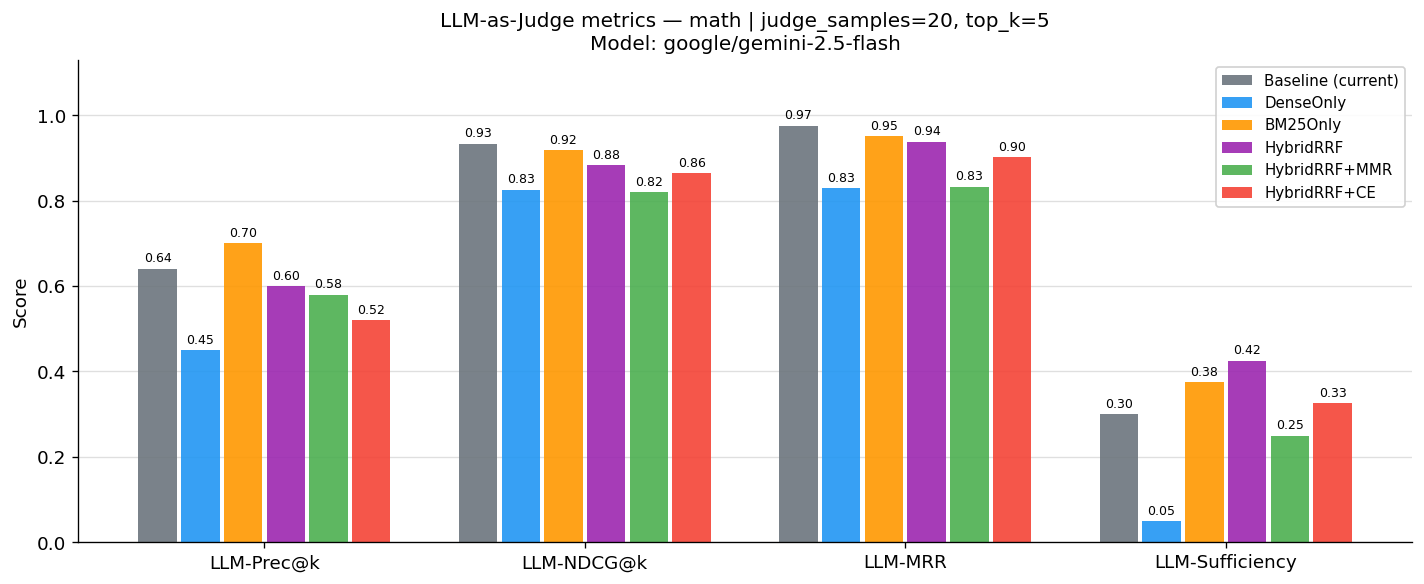

In [6]:
# ── LLM-judge metrics bar chart ───────────────────────────────────────────────
judge_cols = [c for c in ['LLM-Prec@k','LLM-NDCG@k','LLM-MRR','LLM-Sufficiency']
              if c in df_judge.columns]
x       = np.arange(len(judge_cols))
n_arch  = len(df_judge)
width   = 0.8 / n_arch

fig, ax = plt.subplots(figsize=(12, 5))
for i, (arch, row) in enumerate(df_judge.iterrows()):
    offset = (i - n_arch / 2 + 0.5) * width
    vals   = [row.get(m, 0.0) for m in judge_cols]
    bars   = ax.bar(x + offset, vals, width * 0.9,
                    color=COLORS.get(arch, FALLBACK[i]), label=arch, alpha=0.9)
    for bar, val in zip(bars, vals):
        if val > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.009,
                    '{:.2f}'.format(val), ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(judge_cols)
ax.set_ylim(0, 1.13)
ax.set_ylabel('Score')
ax.set_title('LLM-as-Judge metrics — {} | judge_samples={}, top_k={}\nModel: {}'.format(
    DISCIPLINE, JUDGE_SAMPLES, JUDGE_TOPK, judge.model))
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('rag_08_llm_judge.png', bbox_inches='tight')
plt.show()

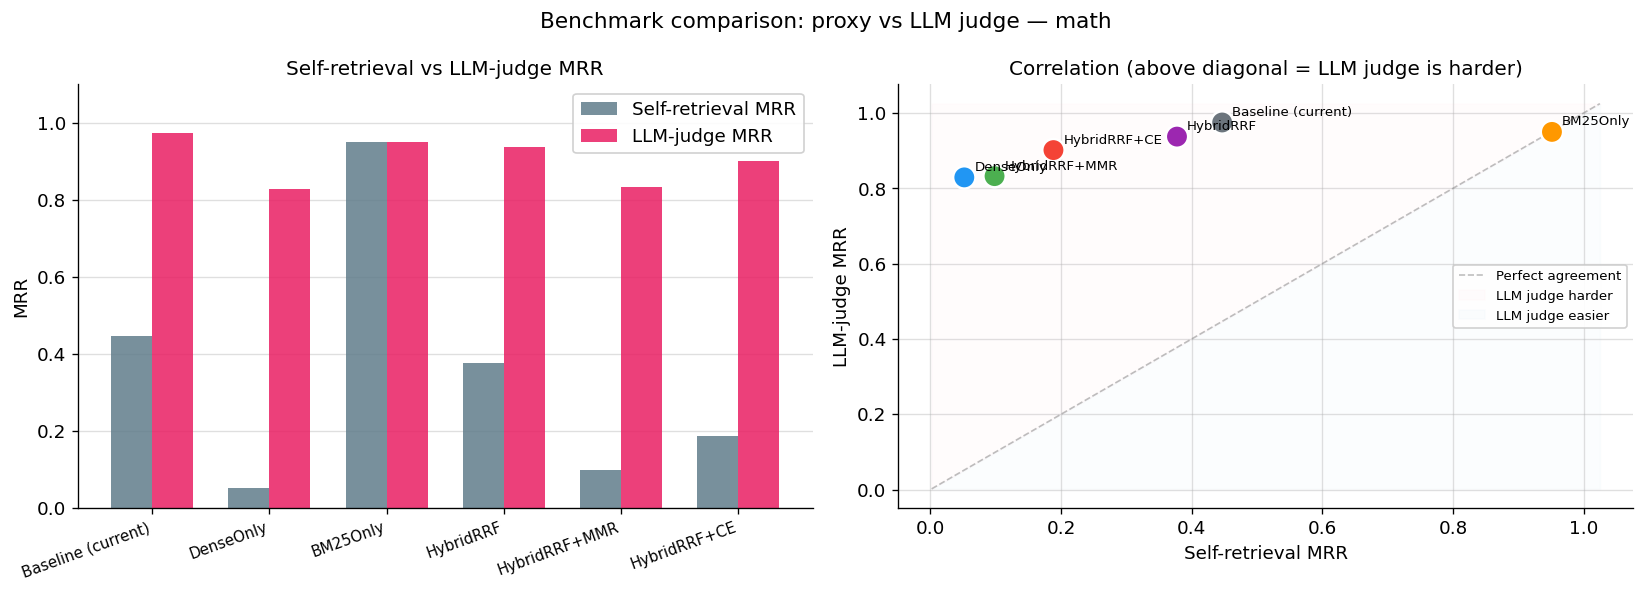

In [10]:
# ── Self-retrieval MRR vs LLM-judge MRR comparison ────────────────────────────
common = [a for a in ARCH_NAMES if a in df_judge.index]
sr_mrr  = [df_main.loc[a, 'MRR']          for a in common]
llm_mrr = [df_judge.loc[a, 'LLM-MRR']     for a in common]
arch_c  = [COLORS.get(a, '#999')           for a in common]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Side-by-side bars
x = np.arange(len(common))
w = 0.35
ax1.bar(x - w/2, sr_mrr,  w, label='Self-retrieval MRR', color='#607D8B', alpha=0.85)
ax1.bar(x + w/2, llm_mrr, w, label='LLM-judge MRR',      color='#E91E63', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(common, rotation=20, ha='right', fontsize=9)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('MRR')
ax1.set_title('Self-retrieval vs LLM-judge MRR')
ax1.legend(framealpha=0.9)
ax1.yaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)

# Correlation scatter
ax2.scatter(sr_mrr, llm_mrr, s=180, c=arch_c, zorder=3, edgecolors='white', lw=1.5)
for arch, sr, llm in zip(common, sr_mrr, llm_mrr):
    ax2.annotate(arch, (sr, llm), xytext=(6, 4), textcoords='offset points', fontsize=8)
lo = min(min(sr_mrr), min(llm_mrr)) - 0.05
hi = max(max(sr_mrr), max(llm_mrr)) + 0.05
ax2.plot([lo, hi], [lo, hi], '--', lw=1, color='grey', alpha=0.5, label='Perfect agreement')
ax2.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.04, color='pink',
                  label='LLM judge harder')
ax2.fill_between([lo, hi], [lo, lo], [lo, hi], alpha=0.04, color='lightblue',
                  label='LLM judge easier')
ax2.set_xlabel('Self-retrieval MRR')
ax2.set_ylabel('LLM-judge MRR')
ax2.set_title('Correlation (above diagonal = LLM judge is harder)')
ax2.legend(framealpha=0.9, fontsize=8)
ax2.xaxis.grid(True, alpha=0.4)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('Benchmark comparison: proxy vs LLM judge — ' + DISCIPLINE, fontsize=13)
plt.tight_layout()
plt.savefig('rag_08b_sr_vs_llm.png', bbox_inches='tight')
plt.show()

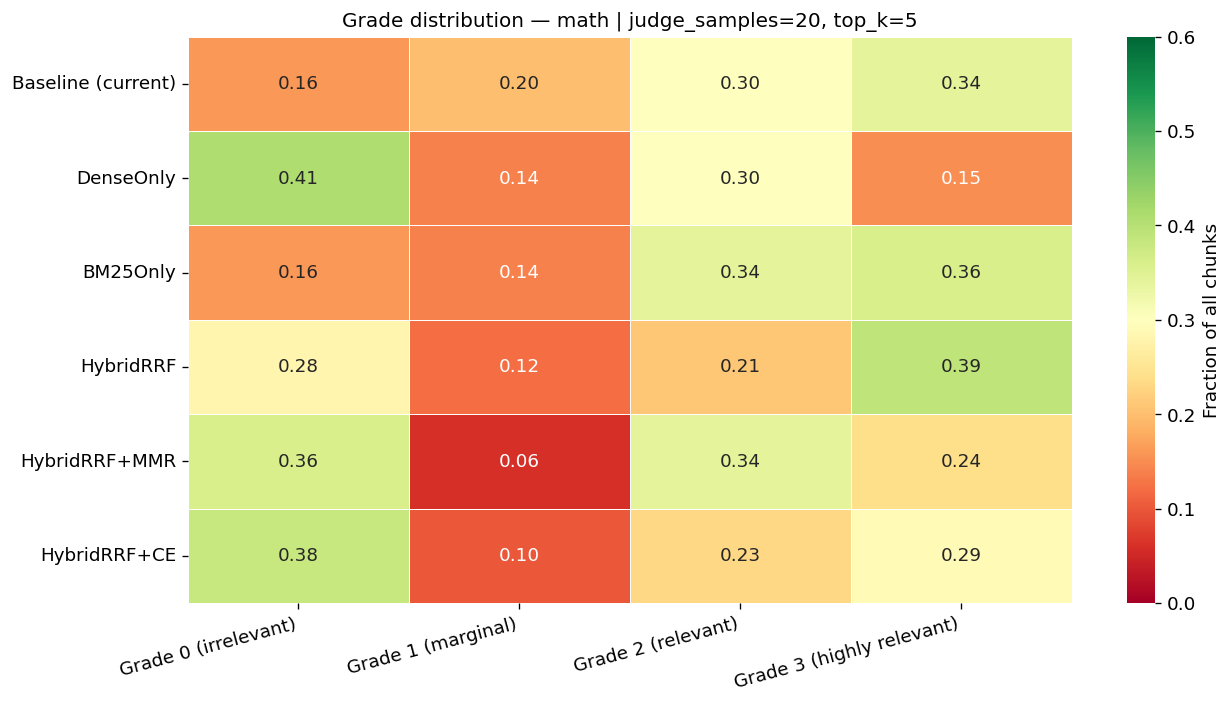

Green (right columns) = more relevant chunks retrieved. Red (left) = more irrelevant.


In [11]:
# ── Grade distribution heatmap ────────────────────────────────────────────────
print('Collecting grade distributions (uses cached responses) ...')
grade_dist = {}
for a in architectures:
    counts = {0: 0, 1: 0, 2: 0, 3: 0}
    random.seed(DEFAULT_SEED)
    for chunk_text in judge_texts:
        q = _generate_query(chunk_text)
        if not q:
            continue
        results = a.retrieve(q, top_k=JUDGE_TOPK)
        for g in judge.rate_chunks(q, results):   # all cached
            counts[g] = counts.get(g, 0) + 1
    total = sum(counts.values()) or 1
    grade_dist[a.name] = {k: v / total for k, v in sorted(counts.items())}

grade_df = pd.DataFrame(grade_dist).T
grade_df.columns = ['Grade 0 (irrelevant)', 'Grade 1 (marginal)',
                    'Grade 2 (relevant)', 'Grade 3 (highly relevant)']

fig, ax = plt.subplots(figsize=(11, max(3, len(grade_df) * 0.75 + 1.5)))
sns.heatmap(grade_df, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
            ax=ax, vmin=0, vmax=0.6, cbar_kws={'label': 'Fraction of all chunks'})
ax.set_title('Grade distribution — {} | judge_samples={}, top_k={}'.format(
    DISCIPLINE, JUDGE_SAMPLES, JUDGE_TOPK))
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.savefig('rag_08c_grade_dist.png', bbox_inches='tight')
plt.show()
print('Green (right columns) = more relevant chunks retrieved. Red (left) = more irrelevant.')

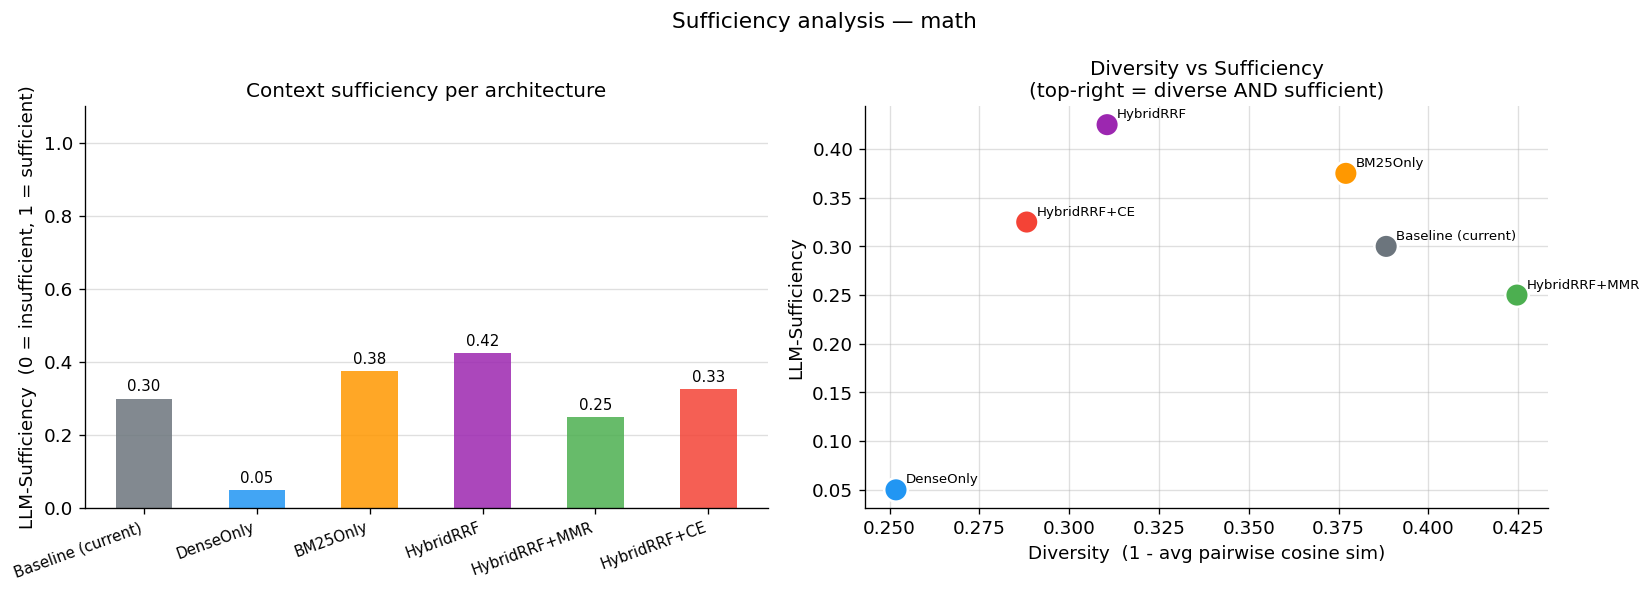

In [12]:
# ── Sufficiency + Diversity-Sufficiency trade-off ─────────────────────────────
if 'LLM-Sufficiency' not in df_judge.columns:
    print('Sufficiency not computed — set compute_sufficiency=True in evaluate_with_judge.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Sufficiency bar
    suff_vals = [df_judge.loc[a, 'LLM-Sufficiency'] for a in common]
    bars = ax1.bar(common, suff_vals,
                   color=[COLORS.get(a, '#999') for a in common], alpha=0.85, width=0.5)
    for bar, val in zip(bars, suff_vals):
        ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.012,
                 '{:.2f}'.format(val), ha='center', va='bottom', fontsize=9)
    ax1.set_xticklabels(common, rotation=20, ha='right', fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('LLM-Sufficiency  (0 = insufficient, 1 = sufficient)')
    ax1.set_title('Context sufficiency per architecture')
    ax1.yaxis.grid(True, alpha=0.4)
    ax1.set_axisbelow(True)

    # Diversity vs Sufficiency
    if 'Diversity' in df_main.columns:
        div_vals  = [df_main.loc[a, 'Diversity']         for a in common if a in df_main.index]
        suff_vals2 = [df_judge.loc[a, 'LLM-Sufficiency'] for a in common if a in df_main.index]
        archs_both = [a for a in common if a in df_main.index]
        ax2.scatter(div_vals, suff_vals2, s=200,
                    c=[COLORS.get(a,'#999') for a in archs_both],
                    zorder=3, edgecolors='white', lw=1.5)
        for arch, d, s in zip(archs_both, div_vals, suff_vals2):
            ax2.annotate(arch, (d, s), xytext=(6, 4), textcoords='offset points', fontsize=8)
        ax2.set_xlabel('Diversity  (1 - avg pairwise cosine sim)')
        ax2.set_ylabel('LLM-Sufficiency')
        ax2.set_title('Diversity vs Sufficiency\n(top-right = diverse AND sufficient)')
        ax2.xaxis.grid(True, alpha=0.4)
        ax2.yaxis.grid(True, alpha=0.4)
        ax2.set_axisbelow(True)

    plt.suptitle('Sufficiency analysis — ' + DISCIPLINE, fontsize=13)
    plt.tight_layout()
    plt.savefig('rag_08d_sufficiency.png', bbox_inches='tight')
    plt.show()

## Summary & Architecture Recommendations

### Decision guide

| Condition | Action |
|---|---|
| HybridRRF MRR ≥ Baseline + 0.05 | Adopt HybridRRF — fast, no extra deps beyond `rank-bm25` |
| HybridRRF+CE MRR ≥ HybridRRF + 0.03 | Add cross-encoder reranking (note: English model, sub-optimal for Russian) |
| Diversity of HybridRRF+MMR visibly higher | Use MMR when context-window efficiency matters more than top-1 precision |
| All gains < 0.03 | Invest in Qdrant index quality (chunk size, model, OCR pipeline) instead |

### Architecture reference

| Architecture | Added cost | When to use |
|---|---|---|
| **Baseline** | — | Current production |
| **DenseOnly** | — | Semantic queries, no keyword exact match needed |
| **BM25Only** | rank-bm25 | Short exact queries; fast fallback |
| **HybridRRF** | rank-bm25 | Best general-purpose upgrade — free combination, robust |
| **HybridRRF+CE** | cross-encoder download (~80 MB) | When top-1 precision is critical |
| **HybridRRF+MMR** | — | When LLM context window must cover diverse subtopics |

### Integration path (minimal change)

```python
# bot/rag/search.py — replace the current merging + rerank block with:
from benchmark_rag import HybridRRFRAG, SharedResources   # or copy the logic inline

# Build SharedResources once at startup (or on first call, cached)
# Then swap retrieve() for the Qdrant vector results + BM25 RRF
```

### Cross-encoder note
The `cross-encoder/ms-marco-MiniLM-L-6-v2` model is trained on English MS-MARCO.  
For Russian academic text, consider `DiTy/cross-encoder-russian-msmarco` as a drop-in replacement.